In [349]:
import pandas as pd

In [350]:
import matplotlib.pyplot as plt

In [351]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv",
    index_col=0
)

In [352]:
df.head()

,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
School DBN,,,,,,,,,,,,,,
01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


In [353]:
df.columns

Index(['School Name', 'School Level', 'Regents Exam', 'Year', 'Total Tested',
       'Mean Score', 'Number Scoring Below 65', 'Percent Scoring Below 65',
       'Number Scoring 65 or Above', 'Percent Scoring 65 or Above',
       'Number Scoring 80 or Above', 'Percent Scoring 80 or Above',
       'Number Scoring CR', 'Percent Scoring CR'],
      dtype='object')

In [354]:
df["Percent Scoring 80 or Above"] = pd.to_numeric(df["Percent Scoring 80 or Above"], errors="coerce")

In [355]:
df_clean = df.dropna(subset=["Percent Scoring 80 or Above"])

In [356]:
df_clean["Percent Scoring 80 or Above"].describe()

,Percent Scoring 80 or Above
count,137109.000000
mean,22.692027
std,26.160987
min,0.000000
25%,2.200000
50%,12.500000
75%,34.500000
max,100.000000


In [357]:
rhhs = df_clean[df_clean["School Name"] == "Richmond Hill High School"]

In [358]:
rhhs["Percent Scoring 80 or Above"].describe()

,Percent Scoring 80 or Above
count,379.00000
mean,12.31372
std,11.22432
min,0.00000
25%,3.70000
50%,9.80000
75%,18.20000
max,71.40000


In [359]:
rhhs_avg = rhhs["Percent Scoring 80 or Above"].mean()
overall_avg = df_clean["Percent Scoring 80 or Above"].mean()

print("RHHS Average:", rhhs_avg)
print("NYC Average:", overall_avg)

RHHS Average: 12.31372031662269
NYC Average: 22.692026781611716


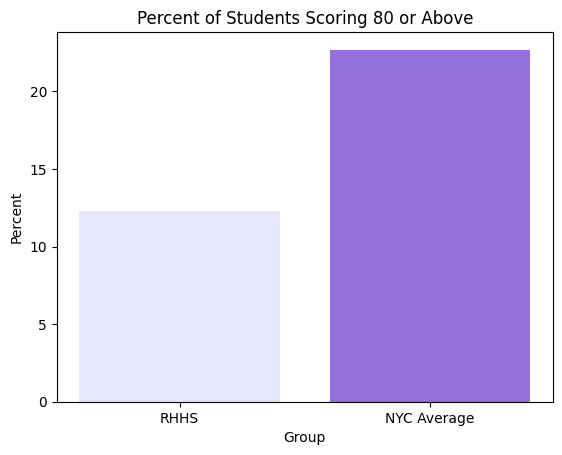

In [371]:
labels = ["RHHS", "NYC Average"]
values = [rhhs_avg, overall_avg]

plt.bar(labels, values, color=['lavender', 'mediumpurple'])
plt.title("Percent of Students Scoring 80 or Above")
plt.ylabel("Percent")
plt.xlabel("Group")
plt.show()

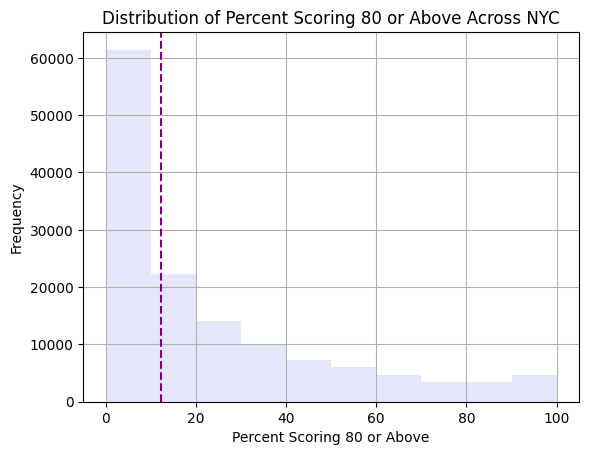

In [381]:
df_clean["Percent Scoring 80 or Above"].hist(color='lavender')
plt.axvline(rhhs_mean, linestyle="dashed", color='purple')
plt.title("Distribution of Percent Scoring 80 or Above Across NYC")
plt.xlabel("Percent Scoring 80 or Above")
plt.ylabel("Frequency")
plt.show()

In [368]:
borough_map ={"M": "Manhattan",
              "X": "Bronx",
              "K": "Brooklyn",
              "Q": "Queens",
              "R": "Staten Island"}
df_clean.loc[:, "Borough"] = df_clean.index.str[2].map(borough_map)

In [363]:
df_clean["Percent Scoring 80 or Above"].describe()

,Percent Scoring 80 or Above
count,137109.000000
mean,22.692027
std,26.160987
min,0.000000
25%,2.200000
50%,12.500000
75%,34.500000
max,100.000000


In [369]:
borough_avg = df_clean.groupby('Borough')['Percent Scoring 80 or Above'].mean().sort_values(ascending=False)
borough_avg

,Percent Scoring 80 or Above
Borough,
Staten Island,30.531814
Queens,29.382659
Manhattan,26.522930
Brooklyn,20.139980
Bronx,15.674596


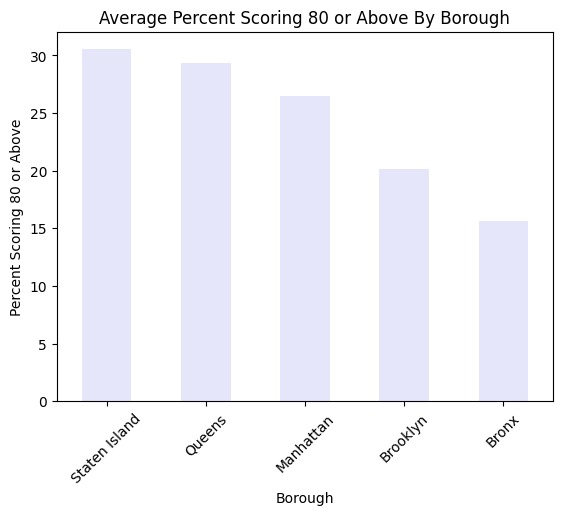

In [373]:
borough_avg.plot(kind="bar", color='lavender')
plt.title("Average Percent Scoring 80 or Above By Borough")
plt.ylabel("Percent Scoring 80 or Above")
plt.xticks(rotation=45)
plt.show()

In [378]:
df_clean.loc[:, 'Total Tested'] = df_clean['Total Tested'].replace('s', '0').astype(int)
df_clean['Total Tested'].describe()

,Total Tested
count,137109.000000
mean,71.583813
std,107.834374
min,6.000000
25%,18.000000
50%,39.000000
75%,82.000000
max,1729.000000


In [379]:
df_clean.loc[:, 'Total Tested'] = df_clean['Total Tested'].replace('s', '0').astype(int)
df_clean['Total Tested'].describe()

,Total Tested
count,137109.000000
mean,71.583813
std,107.834374
min,6.000000
25%,18.000000
50%,39.000000
75%,82.000000
max,1729.000000


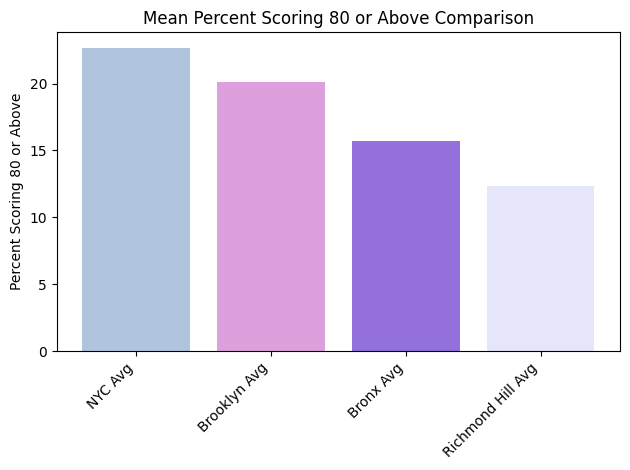

In [374]:
df_clean.loc[:, "Borough"] = df_clean.index.str[2].map(borough_map)

brooklyn_avg_clean = df_clean[df_clean["Borough"] == "Brooklyn"]["Percent Scoring 80 or Above"].mean()
bronx_avg_clean = df_clean[df_clean["Borough"] == "Bronx"]["Percent Scoring 80 or Above"].mean()

labels = ["NYC Avg", "Brooklyn Avg","Bronx Avg", "Richmond Hill Avg"]
vales = [
    overall_avg,
    brooklyn_avg_clean,
    bronx_avg_clean,
    rhhs_avg
]

plt.bar(labels, vales, color=['lightsteelblue', 'plum', 'mediumpurple', 'lavender'])
plt.title("Mean Percent Scoring 80 or Above Comparison")
plt.ylabel("Percent Scoring 80 or Above")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

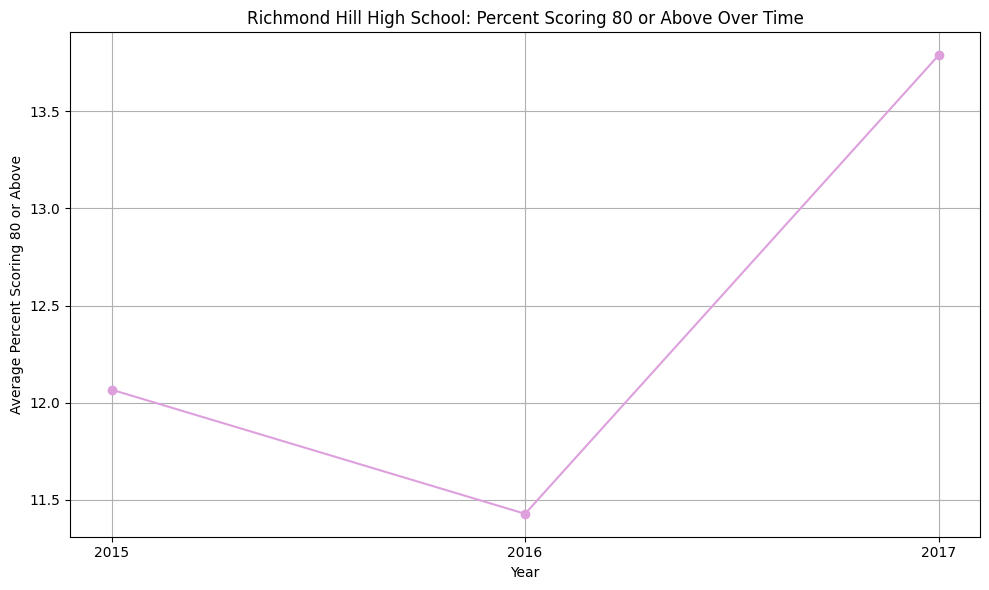

In [380]:
rhhs_yearly_avg = rhhs.groupby('Year')['Percent Scoring 80 or Above'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(rhhs_yearly_avg['Year'], rhhs_yearly_avg['Percent Scoring 80 or Above'], marker='o', color='plum')
plt.title('Richmond Hill High School: Percent Scoring 80 or Above Over Time')
plt.xlabel('Year')
plt.ylabel('Average Percent Scoring 80 or Above')
plt.grid(True)
plt.xticks(rhhs_yearly_avg['Year'].unique())
plt.tight_layout()
plt.show()

## Conclusion

Richmond Hill High School has a lower percentage of students scoring 80 or above compared to the NYC average, as well as the averages for Brooklyn and Bronx. This indicates that fewer students at RHHS are achieving high scores on Regents exams relative to other schools and boroughs. This suggests an opportunity to improve advanced-level student performance.